In [1]:
from ema_workbench import (
    Model, Policy, ema_logging,
    MultiprocessingEvaluator, save_results, load_results, Scenario
)
from ema_workbench.analysis import prim, cart, parcoords
from sklearn.preprocessing import minmax_scale
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from problem_formulation import get_model_for_problem_formulation
from dike_model_function import DikeNetwork

In [2]:
# Enable logging
ema_logging.log_to_stderr(ema_logging.INFO)

# Load model formulation
dike_model, planning_steps = get_model_for_problem_formulation(3)

# Create a "do nothing" policy (no investment in any lever)
do_nothing = Policy("do nothing", **{lev.name: 0 for lev in dike_model.levers})

# Choose number of scenarios
n_scenarios = 5000  # Literature suggests 1000–10,000, this is a balanced choice

# Run model for scenarios with 1 policy
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(scenarios=n_scenarios, policies=[do_nothing])
    save_results(results, "scenario_selection.tar.gz")

[MainProcess/INFO] pool started with 12 workers
[MainProcess/INFO] performing 5000 scenarios * 1 policies * 1 model(s) = 5000 experiments
100%|██████████████████████████████████████| 5000/5000 [06:37<00:00, 12.57it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] results saved successfully to C:\Users\milan\PycharmProjects\EMAworkbench\final assignment\scenario_selection.tar.gz
[MainProcess/INFO] terminating pool


In [3]:
# Load experiments and outcomes from saved file
experiments, outcomes = load_results('scenario_selection.tar.gz')

# Combine into one DataFrame
all_data = pd.concat([experiments, pd.DataFrame(outcomes)], axis=1)

[MainProcess/INFO] results loaded successfully from C:\Users\milan\PycharmProjects\EMAworkbench\final assignment\scenario_selection.tar.gz


In [5]:
import numpy as np

# Define outcomes and preferences
outcome_names = [
    'RfR Total Costs',
    'Expected Evacuation Costs',
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths'
]

preferences = {
    'RfR Total Costs': +1,
    'Expected Evacuation Costs': +1,
    'A.5 Total Costs': +1,
    'A.5_Expected Number of Deaths': +1,
}

# Compute medians and apply relevance mask
medians = {o: np.median(outcomes[o]) for o in outcome_names}
mask = np.ones(len(all_data), dtype=bool)
for o in outcome_names:
    if preferences[o] == +1:
        mask &= all_data[o] >= medians[o]
    else:
        mask &= all_data[o] <= medians[o]

policy_relevant = all_data[mask].copy()

y = np.ones(len(experiments), dtype=bool)
for o in outcome_names:
    if preferences[o] == +1:
        y &= outcomes[o] >= medians[o]  # higher is worse
    else:
        y &= outcomes[o] <= medians[o]  # lower is worse

In [8]:
# Create filtered sets from the mask y
experiments_of_interest = experiments.loc[y]
outcomes_df = pd.DataFrame({k: v[y] for k, v in outcomes.items()})

In [9]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import pdist, squareform
from concurrent.futures import ProcessPoolExecutor
import os
import itertools
import functools
import random

In [10]:

# Import your helper functions
from assignment_10_scenario_selection import find_maxdiverse_scenarios

# STEP 1: Normalize outcomes
scaler = MinMaxScaler()
normalized_outcomes = pd.DataFrame(
    scaler.fit_transform(outcomes_df),
    columns=outcomes_df.columns,
    index=outcomes_df.index
)

# STEP 2: Compute distances
distances = squareform(pdist(normalized_outcomes.values))

# STEP 3: Sample 100,000 combinations of 4
sampled_combinations = [random.sample(range(len(normalized_outcomes)), 4) for _ in range(100000)]

# STEP 4: Parallel diversity scoring
cores = os.cpu_count()
partial_function = functools.partial(find_maxdiverse_scenarios, distances)

with ProcessPoolExecutor(max_workers=cores) as executor:
    worker_data = np.array_split(sampled_combinations, cores)
    results = list(itertools.chain.from_iterable(executor.map(partial_function, worker_data)))

# STEP 5: Select the most diverse set
results.sort(key=lambda entry: entry[0], reverse=True)
diversity_score, best_indices = results[0]

# STEP 6: Print selected scenarios
print(f"\nMost diverse scenario indices: {best_indices}")
selected = experiments.loc[y].iloc[list(best_indices)]
print("\nSelected scenarios:")
print(selected)


Most diverse scenario indices: [1522  842 3863 1733]

Selected scenarios:
      A.0_ID flood wave shape    A.1_Bmax A.1_Brate  A.1_pfail    A.2_Bmax  \
1522                       72  208.020551       1.0   0.518561  189.221703   
842                        98   60.884521       1.0   0.091565  142.770532   
3863                       16  121.913505       1.0   0.965475   67.741462   
1733                       29  287.626246       1.5   0.558052  269.354759   

     A.2_Brate  A.2_pfail    A.3_Bmax A.3_Brate  A.3_pfail  ...  \
1522      10.0   0.733210  171.064996      10.0   0.790473  ...   
842        1.5   0.188848  300.930785      10.0   0.102252  ...   
3863      10.0   0.829347  210.355014       1.0   0.490922  ...   
1733      10.0   0.022112   88.112271      10.0   0.404057  ...   

      A.3_DikeIncrease 2 A.4_DikeIncrease 0  A.4_DikeIncrease 1  \
1522                   0                  0                   0   
842                    0                  0                   0 

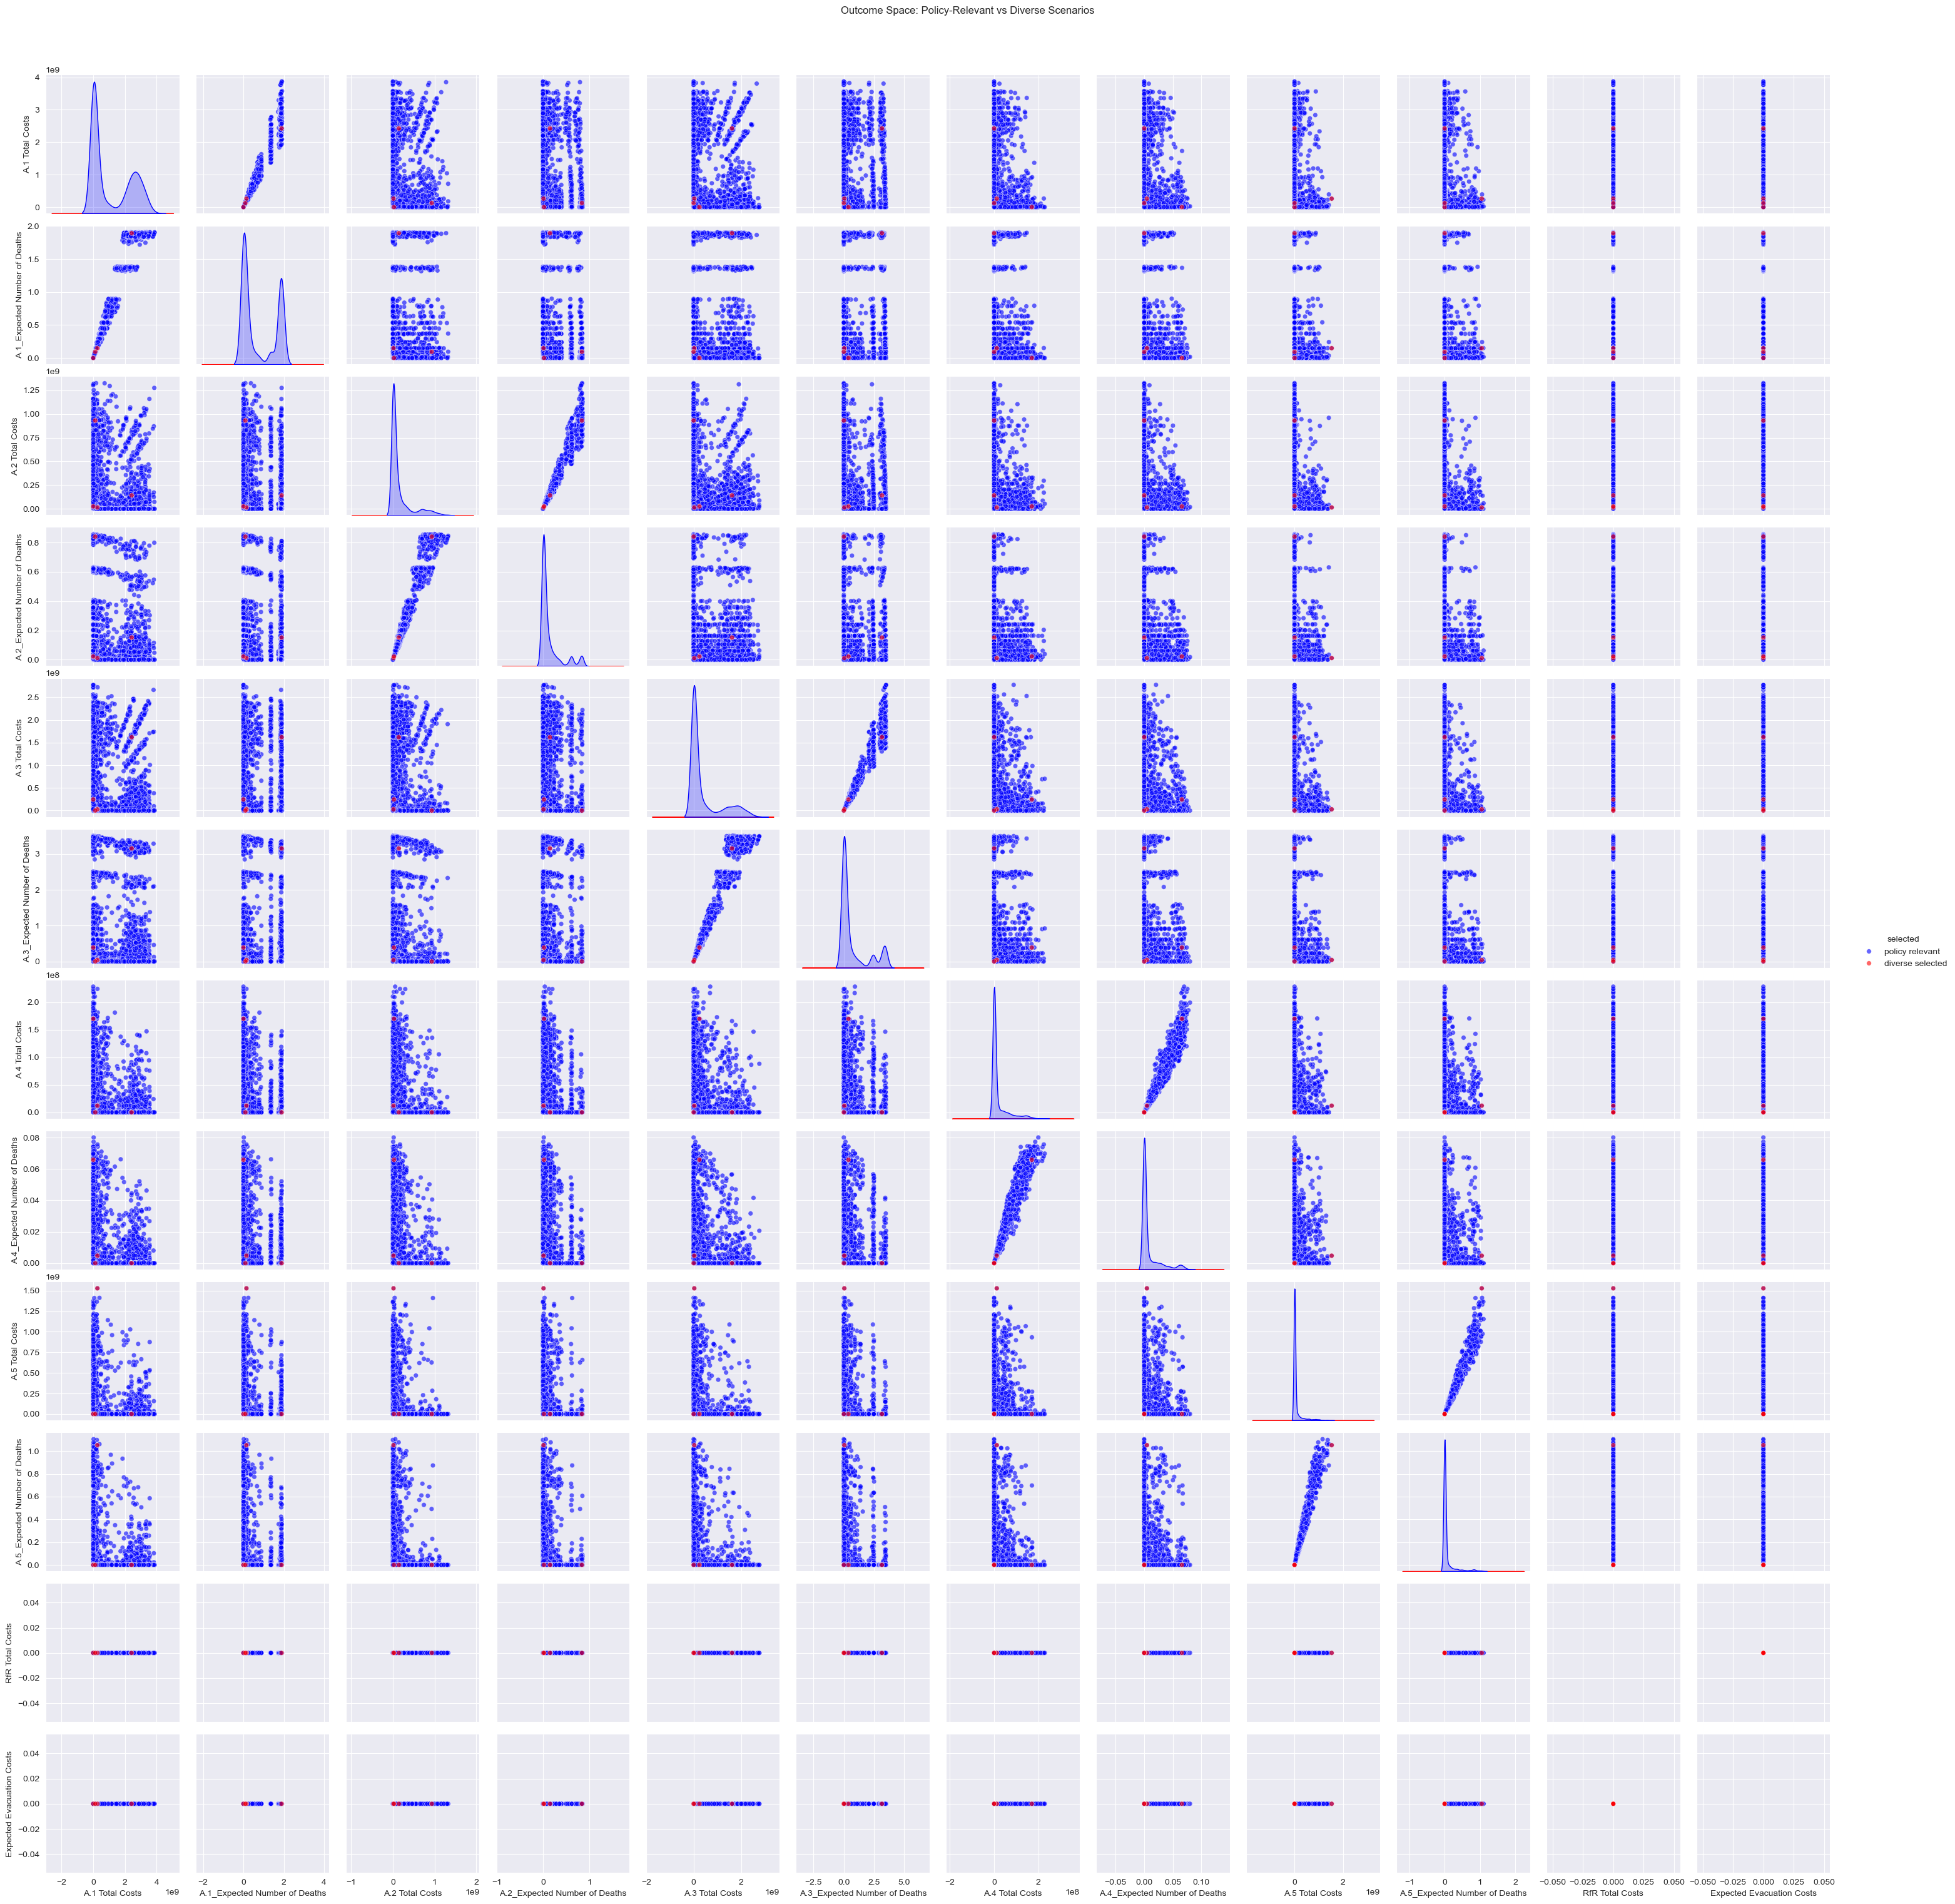

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Label outcomes
outcomes_df = outcomes_df.copy()
outcomes_df['selected'] = 'policy relevant'
selected_outcomes = outcomes_df.iloc[list(best_indices)].copy()
selected_outcomes['selected'] = 'diverse selected'

# Combine and plot
combined_outcomes = pd.concat([outcomes_df, selected_outcomes])

sns.pairplot(
    combined_outcomes,
    vars=outcomes_df.columns.drop('selected'),
    hue='selected',
    palette={'policy relevant': 'blue', 'diverse selected': 'red'},
    plot_kws={'alpha': 0.6, 's': 30}
)
plt.suptitle('Outcome Space: Policy-Relevant vs Diverse Scenarios', y=1.02)
plt.show()

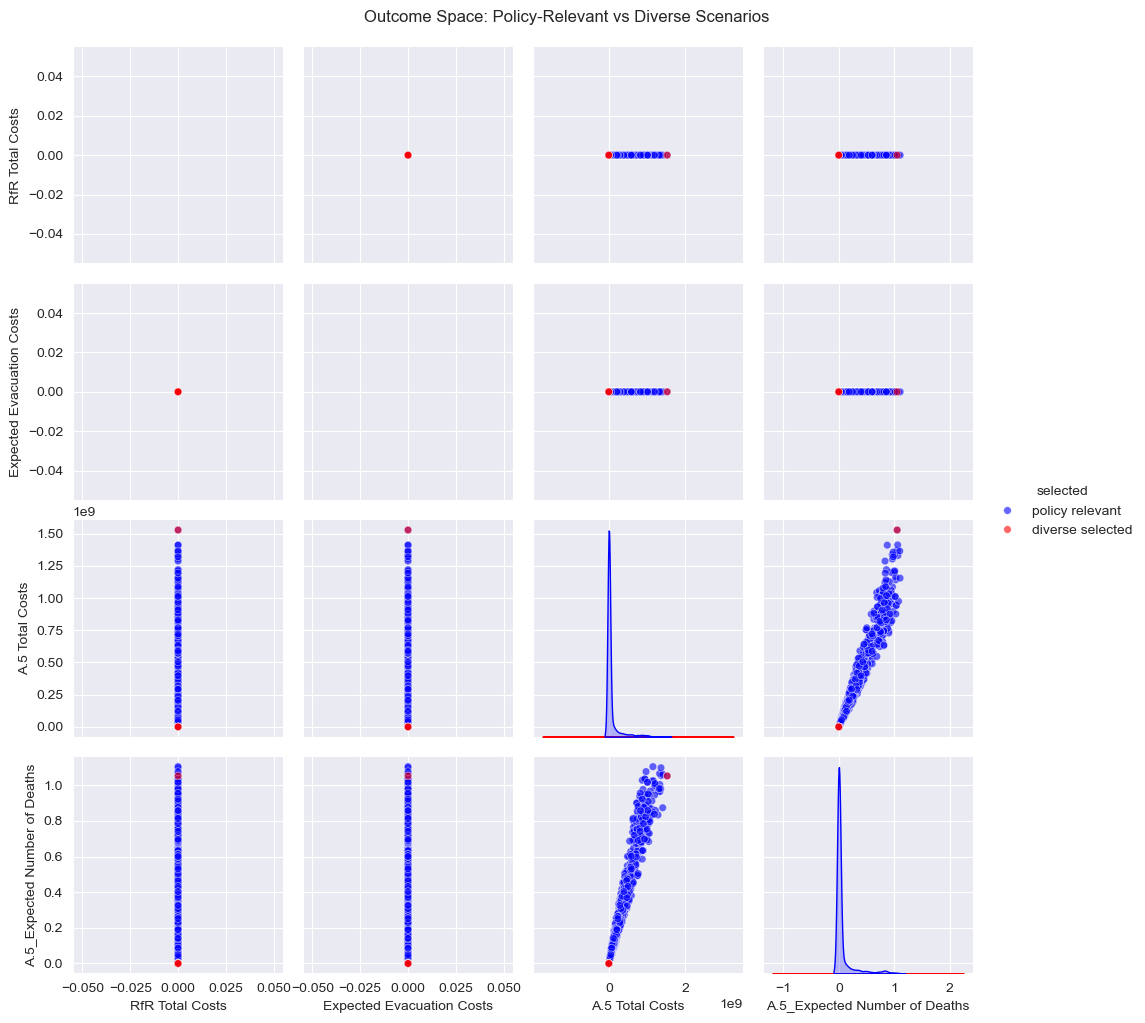

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Label outcomes
outcomes_df = outcomes_df.copy()
outcomes_df['selected'] = 'policy relevant'
selected_outcomes = outcomes_df.iloc[list(best_indices)].copy()
selected_outcomes['selected'] = 'diverse selected'

# Combine and plot only selected outcomes
combined_outcomes = pd.concat([outcomes_df, selected_outcomes])

sns.pairplot(
    combined_outcomes,
    vars=[
        'RfR Total Costs',
        'Expected Evacuation Costs',
        'A.5 Total Costs',
        'A.5_Expected Number of Deaths'
    ],
    hue='selected',
    palette={'policy relevant': 'blue', 'diverse selected': 'red'},
    plot_kws={'alpha': 0.6, 's': 30}
)
plt.suptitle('Outcome Space: Policy-Relevant vs Diverse Scenarios', y=1.02)
plt.show()

[MainProcess/INFO] column policy dropped from analysis because it has only one category
[MainProcess/INFO] column model dropped from analysis because it has only one category
[MainProcess/INFO] 5000 points remaining, containing 1183 cases of interest
[MainProcess/INFO] mean: 1.0, mass: 0.0676, coverage: 0.2857142857142857, density: 1.0 restricted_dimensions: 5


coverage       1.0000
density        0.2366
id             0.0000
k           1183.0000
mass           1.0000
mean           0.2366
n           5000.0000
res_dim        0.0000
Name: 0, dtype: float64

Empty DataFrame
Columns: [(box 0, min), (box 0, max), (box 0, qp value), (box 0, qp value)]
Index: []



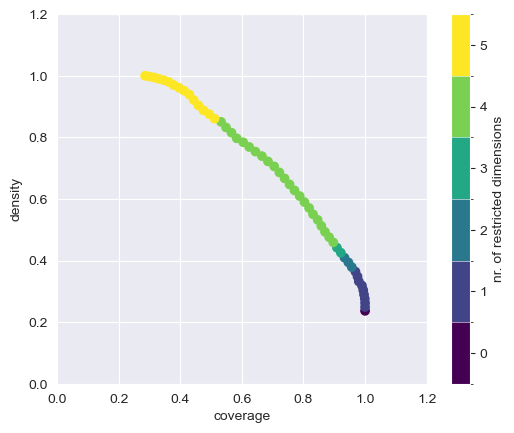

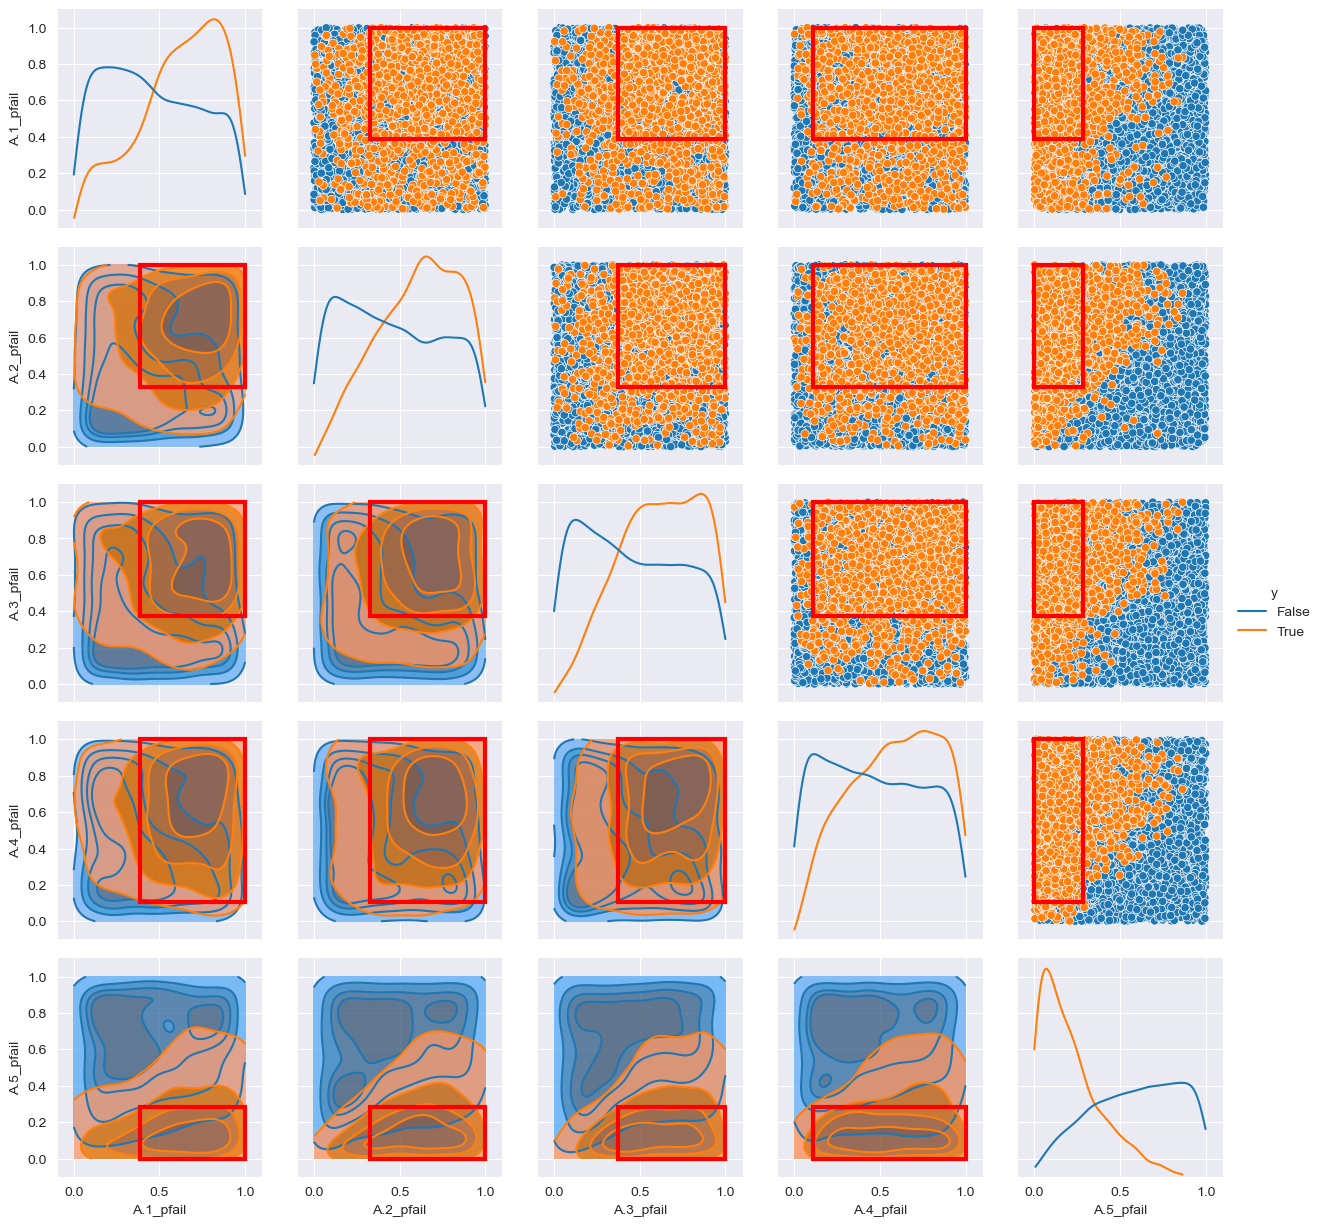

In [14]:
from ema_workbench.analysis import prim

# Binary classification mask for PRIM
y_prim = outcomes_df['A.5_Expected Number of Deaths'] > 0.001

# Use experiments_of_interest (same length as y_prim)

prim_alg = prim.Prim(experiments_of_interest, y_prim, threshold=0.8)
box = prim_alg.find_box()
box.show_tradeoff()
box.inspect(0)
box.show_pairs_scatter()

In [26]:
from ema_workbench.analysis import cart

# Inputs (uncertainties, levers)
x = experiments_of_interest.select_dtypes(include=[np.number])

# Target (can be continuous or binary)
y = outcomes_df['A.5_Expected Number of Deaths'] > 0.001  # classification

# Run CART
cart_results = cart.CART(x=x, y=y)

In [28]:
x

,A.0_ID flood wave shape,A.1_Bmax,A.1_pfail,A.2_Bmax,A.2_pfail,A.3_Bmax,A.3_pfail,A.4_Bmax,A.4_pfail,A.5_Bmax,...,A.2_DikeIncrease 2,A.3_DikeIncrease 0,A.3_DikeIncrease 1,A.3_DikeIncrease 2,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2
0,84,123.031995,0.056431,178.334062,0.995165,72.405318,0.238600,269.965264,0.804384,159.461720,...,0,0,0,0,0,0,0,0,0,0
1,26,210.224770,0.377358,62.157546,0.210864,175.798705,0.924301,218.754634,0.906041,345.898804,...,0,0,0,0,0,0,0,0,0,0
2,122,76.700935,0.331385,54.129610,0.411709,160.924765,0.866847,32.946297,0.788976,336.082745,...,0,0,0,0,0,0,0,0,0,0
3,59,284.953153,0.777939,95.122042,0.256714,328.836980,0.093468,45.426456,0.377107,90.479327,...,0,0,0,0,0,0,0,0,0,0
4,115,147.143328,0.351055,186.748973,0.542301,211.529033,0.759092,205.095735,0.430312,266.288640,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,11,108.016644,0.257816,211.760101,0.667226,179.936944,0.420973,38.358772,0.081102,183.757146,...,0,0,0,0,0,0,0,0,0,0
4996,112,341.049392,0.493712,146.556769,0.364504,300.226784,0.188575,42.197407,0.163292,138.427125,...,0,0,0,0,0,0,0,0,0,0
4997,86,304.803278,0.591719,323.765643,0.444445,307.122783,0.301941,161.904401,0.855376,342.486562,...,0,0,0,0,0,0,0,0,0,0
4998,130,167.248514,0.098058,345.334045,0.333101,144.693216,0.393888,79.534965,0.413883,71.700832,...,0,0,0,0,0,0,0,0,0,0


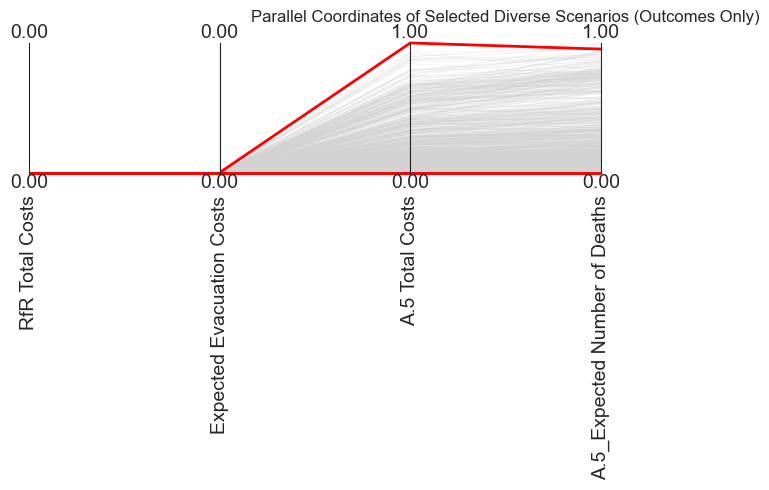

In [34]:
from ema_workbench.analysis import parcoords
from sklearn.preprocessing import minmax_scale
import matplotlib.pyplot as plt

# Merge only outcome values
combined_data = outcomes_df.drop(columns='selected')
vars_of_interest = outcome_names

# Normalize
normalized_all = combined_data[vars_of_interest].copy()
normalized_all[vars_of_interest] = minmax_scale(normalized_all[vars_of_interest])

# Selected 4
selected_out = normalized_all.iloc[list(best_indices)]

# Plot
limits = parcoords.get_limits(normalized_all)
ax = parcoords.ParallelAxes(limits)
ax.plot(normalized_all, color='lightgrey', lw=0.5, alpha=0.3)
ax.plot(selected_out, color='red', lw=2)
plt.title('Parallel Coordinates of Selected Diverse Scenarios (Outcomes Only)')
plt.show()

In [36]:
selected

,A.0_ID flood wave shape,A.1_Bmax,A.1_Brate,A.1_pfail,A.2_Bmax,A.2_Brate,A.2_pfail,A.3_Bmax,A.3_Brate,A.3_pfail,...,A.3_DikeIncrease 2,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,scenario,policy,model
1522,72,208.020551,1.0,0.518561,189.221703,10.0,0.733210,171.064996,10.0,0.790473,...,0,0,0,0,0,0,0,1522,do nothing,dikesnet
842,98,60.884521,1.0,0.091565,142.770532,1.5,0.188848,300.930785,10.0,0.102252,...,0,0,0,0,0,0,0,842,do nothing,dikesnet
3863,16,121.913505,1.0,0.965475,67.741462,10.0,0.829347,210.355014,1.0,0.490922,...,0,0,0,0,0,0,0,3863,do nothing,dikesnet
1733,29,287.626246,1.5,0.558052,269.354759,10.0,0.022112,88.112271,10.0,0.404057,...,0,0,0,0,0,0,0,1733,do nothing,dikesnet


In [37]:
from ema_workbench import Scenario

scenarios = [
    Scenario(f"Scenario {i}", **row.to_dict())
    for i, row in selected.iterrows()
]

In [45]:
from ema_workbench import ema_logging, Scenario
from problem_formulation import get_model_for_problem_formulation  # ensure this is correct
from ema_workbench.em_framework.optimization import ArchiveLogger, EpsilonProgress, to_problem, epsilon_nondominated, HypervolumeMetric
from ema_workbench import MultiprocessingEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import os


def clean_name(name, prefix="L_"):
    clean = name.replace(" ", "_").replace(".", "_").replace("-", "_")
    if clean[0].isdigit():
        clean = prefix + clean
    return clean

def clean_column_names(df, prefix="L_"):
    df = df.copy()
    df.columns = [clean_name(col, prefix=prefix) for col in df.columns]
    return df

objectives_of_interest = [
    "A.5 Total Costs",
    "A.5_Expected Number of Deaths"
]

cleaned_objectives_of_interest = [clean_name(o, "O_") for o in objectives_of_interest]

if __name__ == "__main__":
    ema_logging.log_to_stderr(ema_logging.INFO)

    for scenario in scenarios:
        for run_id in range(5):
            print(f"\n🔁 Running optimization for scenario: {scenario.name}, run: {run_id}")

            model, steps = get_model_for_problem_formulation(3)

            reference_values = {
                "Bmax": 175,
                "Brate": 1.5,
                "pfail": 0.5,
                "discount rate 0": 3.5,
                "discount rate 1": 3.5,
                "discount rate 2": 3.5,
                "ID flood wave shape": 4,
            }

            scen1 = {}
            for key in model.uncertainties:
                name_split = key.name.split("_")
                key_id = name_split[1] if len(name_split) > 1 else key.name
                scen1[key.name] = reference_values[key_id]

            ref_scenario = Scenario("reference", **scen1)

            cleaned_lever_names = [clean_name(l.name, "L_") for l in model.levers]
            cleaned_outcome_names = [clean_name(o.name, "O_") for o in model.outcomes]

            archive_path = f"./archives/optimization_{scenario.name}_run{run_id}.tar.gz"
            os.makedirs("./archives", exist_ok=True)
            if os.path.exists(archive_path):
                os.remove(archive_path)

            convergence_metrics = [
                ArchiveLogger(
                    "./archives",
                    cleaned_lever_names,
                    cleaned_outcome_names,
                    base_filename=f"optimization_{scenario.name}_run{run_id}.tar.gz",
                ),
                EpsilonProgress(),
            ]

            with MultiprocessingEvaluator(model) as evaluator:
                results, convergence = evaluator.optimize(
                    nfe=100,
                    searchover='levers',
                    convergence=convergence_metrics,
                    epsilons=[0.01] * len(model.outcomes),
                    reference=ref_scenario
                )

            archive_test = ArchiveLogger.load_archives(archive_path)
            archive_test_clean = {k: clean_column_names(v) for k, v in archive_test.items()}
            reference_set_clean = clean_column_names(results)

            for lever in model.levers:
                lever.name = clean_name(lever.name, "L_")

            names_to_keep = []
            for o in model.outcomes:
                cleaned = clean_name(o.name, prefix="O_")
                if cleaned in cleaned_objectives_of_interest:
                    names_to_keep.append(o.name)

            for name in list(model.outcomes.keys()):
                if name not in names_to_keep:
                    del model.outcomes[name]

            for o in model.outcomes:
                o.name = clean_name(o.name, prefix="O_")

            print(f"✅ Filtered outcomes for scenario {scenario.name} (run {run_id}):")
            for o in model.outcomes:
                print(o.name)

            problem = to_problem(model, searchover="levers")
            problem._outcome_names = cleaned_objectives_of_interest
            cleaned_lever_names = problem.parameter_names

            reference_set_reduced = reference_set_clean[cleaned_objectives_of_interest + cleaned_lever_names]
            archive_test_reduced = {
                k: v[cleaned_objectives_of_interest + cleaned_lever_names] for k, v in archive_test_clean.items()
            }

            reference_set_final = reference_set_reduced.copy()

            if len(reference_set_final) == 0:
                print(f"⚠️ No non-dominated solutions in run {run_id} of {scenario.name}. Skipping HV calc.")
                continue  # skip the rest of this run

            def calculate_convergence_metrics(problem, archives_file, reference_set):
                hv = HypervolumeMetric(reference_set, problem)
                metrics = []
                for nfe, archive in archives_file.items():
                    scores = {"hypervolume": hv.calculate(archive), "nfe": nfe}
                    metrics.append(scores)
                df = pd.DataFrame.from_dict(metrics)
                df.sort_values(by="nfe", inplace=True, ignore_index=True)
                return df

            metrics = calculate_convergence_metrics(problem, archive_test_reduced, reference_set_final)
            if metrics.empty:
                print(f"⚠️ No valid metrics in run {run_id} of {scenario.name}.")
                continue
            print(metrics)

            epsilon_nfe = convergence["nfe"]
            epsilon_values = convergence["epsilon_progress"]
            hv_nfe = metrics["nfe"]
            hv_values = metrics["hypervolume"]


🔁 Running optimization for scenario: Scenario 1522, run: 0


[MainProcess/INFO] pool started with 12 workers
100%|████████████████████████████████████████| 100/100 [00:07<00:00, 13.90it/s]
[MainProcess/INFO] optimization completed, found 58 solutions
[MainProcess/INFO] terminating pool


✅ Filtered outcomes for scenario Scenario 1522 (run 0):
A_5_Total_Costs
A_5_Expected_Number_of_Deaths
   hypervolume  nfe
0          0.0    0
1          1.0  100

🔁 Running optimization for scenario: Scenario 1522, run: 1


[MainProcess/INFO] pool started with 12 workers
100%|████████████████████████████████████████| 100/100 [00:08<00:00, 12.21it/s]
[MainProcess/INFO] optimization completed, found 63 solutions
[MainProcess/INFO] terminating pool


✅ Filtered outcomes for scenario Scenario 1522 (run 1):
A_5_Total_Costs
A_5_Expected_Number_of_Deaths
   hypervolume  nfe
0     0.000000    0
1     0.975755  100

🔁 Running optimization for scenario: Scenario 1522, run: 2


...

✅ Filtered outcomes for scenario Scenario 1733 (run 2):
A_5_Total_Costs
A_5_Expected_Number_of_Deaths
   hypervolume  nfe
0     0.000000    0
1     0.953603  100

🔁 Running optimization for scenario: Scenario 1733, run: 3


[MainProcess/INFO] pool started with 12 workers
100%|████████████████████████████████████████| 100/100 [00:07<00:00, 13.99it/s]
[MainProcess/INFO] optimization completed, found 66 solutions
[MainProcess/INFO] terminating pool


✅ Filtered outcomes for scenario Scenario 1733 (run 3):
A_5_Total_Costs
A_5_Expected_Number_of_Deaths
   hypervolume  nfe
0          0.0    0
1          1.0  100

🔁 Running optimization for scenario: Scenario 1733, run: 4


[MainProcess/INFO] pool started with 12 workers
100%|████████████████████████████████████████| 100/100 [00:07<00:00, 13.61it/s]
[MainProcess/INFO] optimization completed, found 72 solutions
[MainProcess/INFO] terminating pool


✅ Filtered outcomes for scenario Scenario 1733 (run 4):
A_5_Total_Costs
A_5_Expected_Number_of_Deaths
   hypervolume  nfe
0     0.000000    0
1     0.999432  100


In [49]:
cleaned_lever_names

['L_0_RfR_0',
 'L_0_RfR_1',
 'L_0_RfR_2',
 'L_1_RfR_0',
 'L_1_RfR_1',
 'L_1_RfR_2',
 'L_2_RfR_0',
 'L_2_RfR_1',
 'L_2_RfR_2',
 'L_3_RfR_0',
 'L_3_RfR_1',
 'L_3_RfR_2',
 'L_4_RfR_0',
 'L_4_RfR_1',
 'L_4_RfR_2',
 'EWS_DaysToThreat',
 'A_1_DikeIncrease_0',
 'A_1_DikeIncrease_1',
 'A_1_DikeIncrease_2',
 'A_2_DikeIncrease_0',
 'A_2_DikeIncrease_1',
 'A_2_DikeIncrease_2',
 'A_3_DikeIncrease_0',
 'A_3_DikeIncrease_1',
 'A_3_DikeIncrease_2',
 'A_4_DikeIncrease_0',
 'A_4_DikeIncrease_1',
 'A_4_DikeIncrease_2',
 'A_5_DikeIncrease_0',
 'A_5_DikeIncrease_1',
 'A_5_DikeIncrease_2']

In [52]:
convergence

,epsilon_progress,nfe
0,0,0
1,84,100


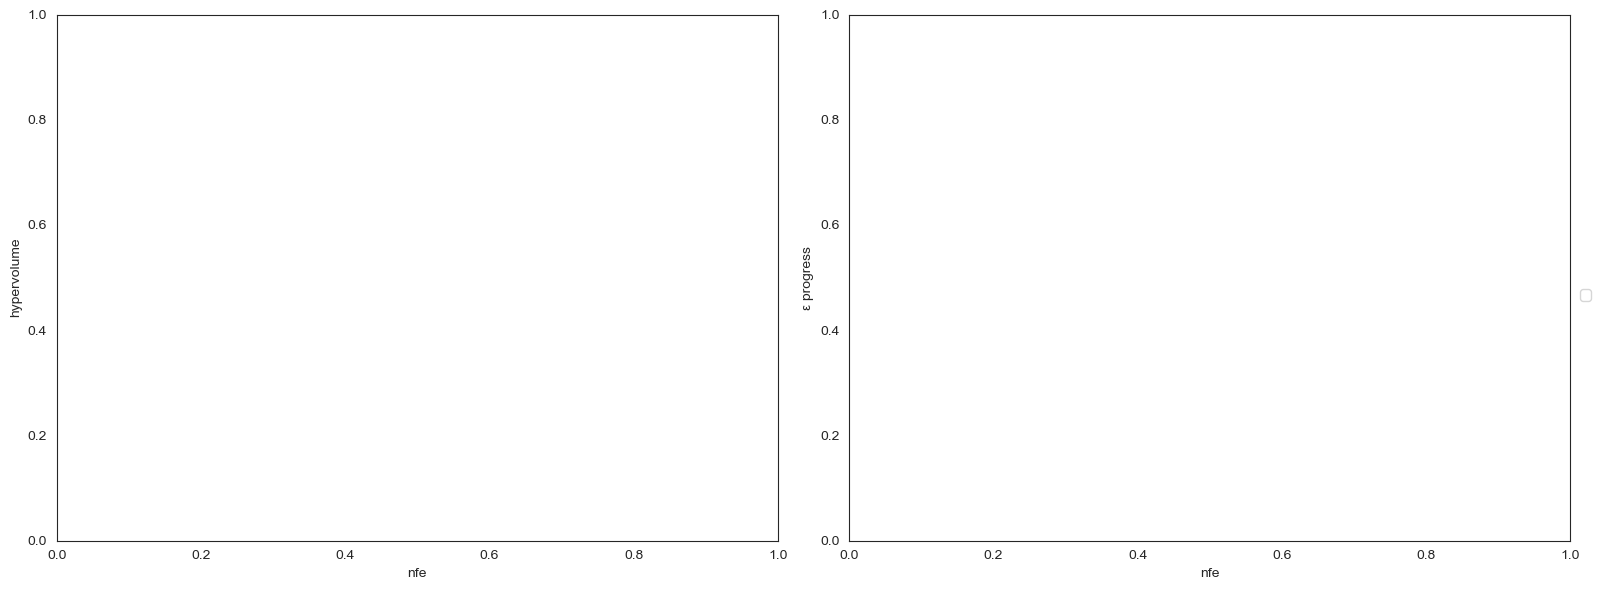

In [55]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from ema_workbench.em_framework.optimization import ArchiveLogger, HypervolumeMetric
from ema_workbench.em_framework.optimization import EpsilonProgress, to_problem
from problem_formulation import get_model_for_problem_formulation  # Make sure this works

# === CONFIGURE ===
scenarios = ["842", "1522", "1733", "3863"]  # replace with your actual scenario names
n_runs = 5
archive_dir = "./archives"

objectives_of_interest = [
    "A.5 Total Costs",
    "A.5_Expected Number of Deaths"
]

def clean_name(name, prefix="L_"):
    clean = name.replace(" ", "_").replace(".", "_").replace("-", "_")
    if clean[0].isdigit():
        clean = prefix + clean
    return clean

cleaned_objectives_of_interest = [clean_name(o, "O_") for o in objectives_of_interest]

# === LOAD MODEL ONCE FOR CONSISTENCY ===
model, _ = get_model_for_problem_formulation(3)

# Clean levers and outcomes
cleaned_lever_names = [clean_name(l.name, "L_") for l in model.levers]
for lever in model.levers:
    lever.name = clean_name(lever.name, "L_")

names_to_keep = []
for o in model.outcomes:
    cleaned = clean_name(o.name, prefix="O_")
    if cleaned in cleaned_objectives_of_interest:
        names_to_keep.append(o.name)

for name in list(model.outcomes.keys()):
    if name not in names_to_keep:
        del model.outcomes[name]

for o in model.outcomes:
    o.name = clean_name(o.name, prefix="O_")

problem = to_problem(model, searchover="levers")
problem._outcome_names = cleaned_objectives_of_interest
cleaned_lever_names = problem.parameter_names

# === AGGREGATE RESULTS ===
hv_data = {}
epsilon_data = {}

for scenario in scenarios:
    hv_data[scenario] = []
    epsilon_data[scenario] = []

    for run_id in range(n_runs):
        archive_path = f"{archive_dir}/optimization_{scenario}_run{run_id}.tar.gz"
        if not os.path.exists(archive_path):
            continue

        # Load archive
        try:
            archive = ArchiveLogger.load_archives(archive_path)
            print(f"\n🧪 Scenario {scenario} | Run {run_id}")
            print(f"  🔍 Loaded archive: {archive_path}")

            if not archive:
                print(f"  ⚠️ Archive loaded but is empty.")
                continue

            # Combine generations
            df = pd.concat(archive.values(), ignore_index=True)

            if df.empty:
                print(f"  ⚠️ Combined dataframe is empty after concat.")
                continue

            print(f"  ✅ Loaded {len(df)} rows")
            print(f"  📊 Columns in archive: {df.columns.tolist()[:5]} ...")  # print first 5 column names

            try:
            # Clean column names
                df.columns = [clean_name(c, "L_") if c in cleaned_lever_names else clean_name(c, "O_") for c in df.columns]

            # Try to extract ref set
                ref_set = df[cleaned_objectives_of_interest + cleaned_lever_names]
                print(f"  ✅ Ref set shape: {ref_set.shape}")
            except Exception as e:
                print(f"  ❌ Failed to extract reference set: {e}")
                continue
        except:
            print(f"❌ Could not load: {archive_path}")
            continue

        # Build hypervolume reference set
        #df = pd.concat(archive.values(), ignore_index=True)
        #df.columns = [clean_name(c, "L_") if c in cleaned_lever_names else clean_name(c, "O_") for c in df.columns]
        #ref_set = df[cleaned_objectives_of_interest + cleaned_lever_names]

        if len(ref_set) == 0:
            continue

        # Hypervolume calculation
        hv_metric = HypervolumeMetric(ref_set, problem)
        metrics = []
        for nfe, gen_df in archive.items():
            gen_df.columns = [clean_name(c, "L_") if c in cleaned_lever_names else clean_name(c, "O_") for c in gen_df.columns]
            reduced = gen_df[cleaned_objectives_of_interest + cleaned_lever_names]
            score = hv_metric.calculate(reduced)
            metrics.append({'nfe': nfe, 'hypervolume': score})

        hv_df = pd.DataFrame(metrics).sort_values("nfe")
        hv_data[scenario].append(hv_df)

        # Simulate EpsilonProgress from convergence archive (only if stored separately)
        # Here we skip this unless you saved the convergence metrics somewhere
        # epsilon_df = pd.DataFrame({"nfe": ..., "epsilon_progress": ...})
        # epsilon_data[scenario].append(epsilon_df)

# === PLOT ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
colors = {"842": "blue", "1522": "green", "1733": "red", "3863": "orange"}

# Plot hypervolume
for scenario in hv_data:
    for run in hv_data[scenario]:
        axes[0].plot(run["nfe"], run["hypervolume"], label=scenario, color=colors[scenario], alpha=0.8)

axes[0].set_ylabel("hypervolume")
axes[0].set_xlabel("nfe")

# Plot epsilon progress — if you have it
# for scenario in epsilon_data:
#     for run in epsilon_data[scenario]:
#         axes[1].plot(run["nfe"], run["epsilon_progress"], label=scenario, color=colors[scenario], alpha=0.8)

axes[1].set_ylabel("ε progress")
axes[1].set_xlabel("nfe")

# Legend once
handles, labels = axes[0].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
fig.legend(unique_labels.values(), unique_labels.keys(), loc='center right')

plt.tight_layout()
plt.show()